In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import mean_squared_error, accuracy_score, precision_score, recall_score, f1_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from statsmodels.othermod.betareg import BetaModel


column_names = []

with open("communities.names") as f:
    for line in f:
        if line.startswith("@attribute"):
            column_names.append(line.split(" ")[1])

# Load data
df = pd.read_csv("communities.data",
                 names=column_names,
                 na_values="?")

df = df.apply(pd.to_numeric, errors="coerce")

#Drop irrelevent columns
df = df.drop(columns=["state", "county", "community", "communityname", "fold"], errors="ignore")
df = df[df['pctUrban'] > 0.75]



In [ ]:
economic_vars = [
'PctPopUnderPov',
'perCapInc',
'medIncome',
'PctUnemployed',
'PctNotHSGrad',
'PctBSorMore',
'pctWSocSec',
'pctWInvInc',
'MedRentPctHousInc',
'PctOccupMgmtProf'
]

structural_vars = [
'PopDens',
'PctUsePubTrans',
'PctPersDenseHous',
'PctVacantBoarded',
'HousVacant',
'PctHousNoPhone',
'PctHousLess3BR',
'PctHousOwnOcc',
'NumInShelters',
'LandArea'
]

demographic_vars = [
'PctKids2Par',
'PctIlleg',
'racePctWhite',
'racepctblack',
'FemalePctDiv',
'TotalPctDiv',
'agePct12t29',
'population',
'PctLargHouseFam',
'PctSpeakEnglOnly'
]

target = ['ViolentCrimesPerPop']
features = economic_vars + structural_vars + demographic_vars
econ = df[economic_vars]
struct = df[structural_vars]
demo = df[demographic_vars]
totalSample = df[features]
clean_df = df.dropna()



In [69]:
st_total = pd.DataFrame({
    "Mean": totalSample.mean(),
    "Median": totalSample.median(),
    "Std Dev": totalSample.std(),
    "Min": totalSample.min(),
    "Max": totalSample.max()
})

st_total = st_total.round(2)
st_total

,Mean,Median,Std Dev,Min,Max
PctPopUnderPov,0.26,0.19,0.21,0.00,1.00
perCapInc,0.39,0.35,0.20,0.01,1.00
medIncome,0.41,0.37,0.21,0.00,1.00
PctUnemployed,0.33,0.29,0.19,0.00,1.00
PctNotHSGrad,0.35,0.32,0.20,0.00,1.00
PctBSorMore,0.39,0.34,0.22,0.00,1.00
pctWSocSec,0.45,0.45,0.17,0.05,1.00
pctWInvInc,0.52,0.51,0.18,0.00,1.00
MedRentPctHousInc,0.49,0.49,0.17,0.00,1.00
PctOccupMgmtProf,0.47,0.44,0.20,0.00,1.00


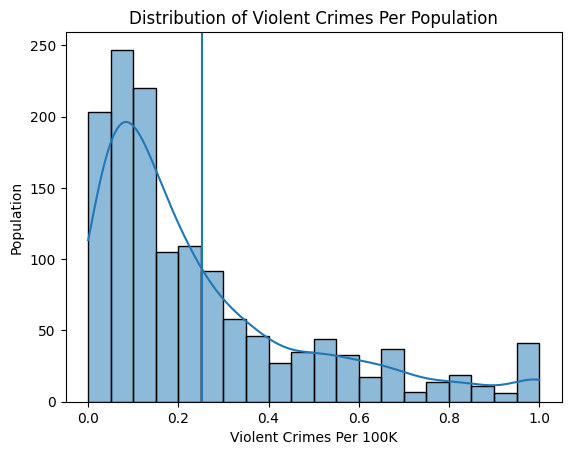

In [70]:
plt.figure()
sns.histplot(df["ViolentCrimesPerPop"], kde=True)
plt.axvline(df["ViolentCrimesPerPop"].mean())
plt.title("Distribution of Violent Crimes Per Population")
plt.xlabel("Violent Crimes Per 100K")
plt.ylabel("Population")
plt.show()

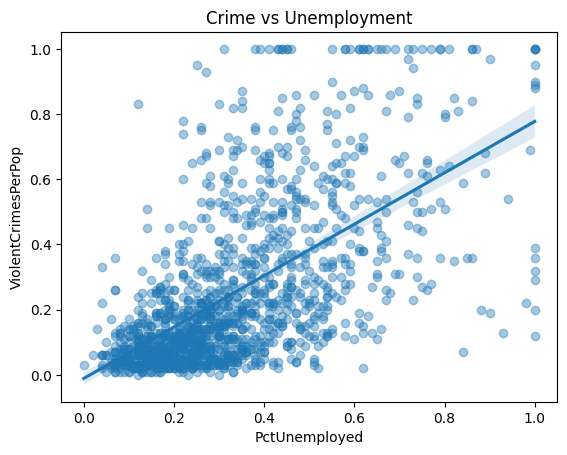

In [73]:
plt.figure()
sns.regplot(x="PctUnemployed",
            y="ViolentCrimesPerPop",
            data=df,
            scatter_kws={'alpha':0.4})
plt.title("Crime vs Unemployment")
plt.show()

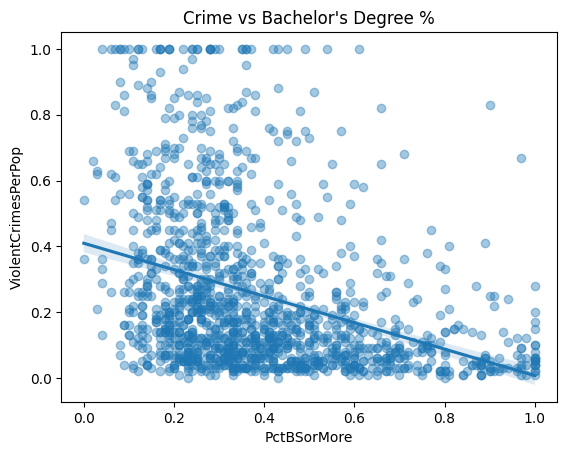

In [74]:
plt.figure()
sns.regplot(x="PctBSorMore",
            y="ViolentCrimesPerPop",
            data=df,
            scatter_kws={'alpha':0.4})
plt.title("Crime vs Bachelor's Degree %")
plt.show()

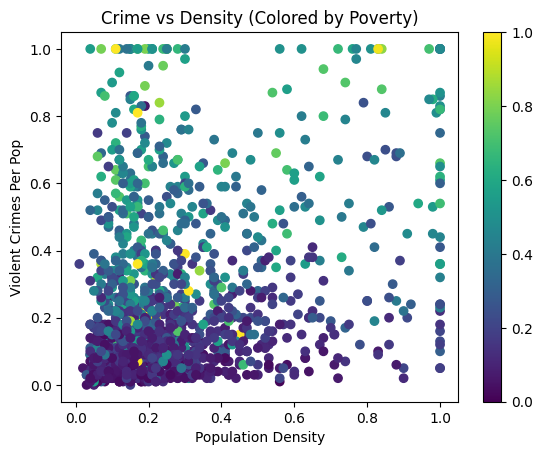

In [77]:
plt.figure()
scatter = plt.scatter(df["PopDens"],
                      df["ViolentCrimesPerPop"],
                      c=df["PctPopUnderPov"])

plt.colorbar(scatter)
plt.xlabel("Population Density")
plt.ylabel("Violent Crimes Per Pop")
plt.title("Crime vs Density (Colored by Poverty)")
plt.show()

In [ ]:
#Linear Regression with clean data
#Train-Test aplit
X = clean_df[features]
y = clean_df['ViolentCrimesPerPop']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

#linear Regression model
linreg = LinearRegression()
linreg.fit(X_train, y_train)

#Predictions
y_pred = linreg.predict(X_test)

#MSE
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

threshold = 0.1
y_test_binary = (y_test > threshold).astype(int)
y_pred_binary = (y_pred > threshold).astype(int)
accuracy = accuracy_score(y_test_binary, y_pred_binary)
precision = precision_score(y_test_binary, y_pred_binary)
recall = recall_score(y_test_binary, y_pred_binary)
f1 = f1_score(y_test_binary, y_pred_binary)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

cv_scores = cross_val_score(
    linreg,
    X,
    y,
    cv=10,
    scoring='neg_mean_squared_error'
)

cv_mse = -cv_scores.mean()
lin_coefs = pd.Series(linreg.coef_, index=features)
top5_linear = lin_coefs.abs().sort_values(ascending=False).head(5)
print("10-Fold CV MSE:", cv_mse)
print("Top 5 Linear Regression Features:")
print(top5_linear.to_string())

Mean Squared Error: 0.033242613522543873
Accuracy: 0.921875
Precision: 0.9666666666666667
Recall: 0.9508196721311475
F1 Score: 0.9586776859504132
10-Fold CV MSE: 0.029505581394302965
Top 5 Linear Regression Features:
pctWInvInc       1.160741
PctNotHSGrad     0.661413
PctBSorMore      0.580195
PctKids2Par      0.536938
PctHousOwnOcc    0.353574


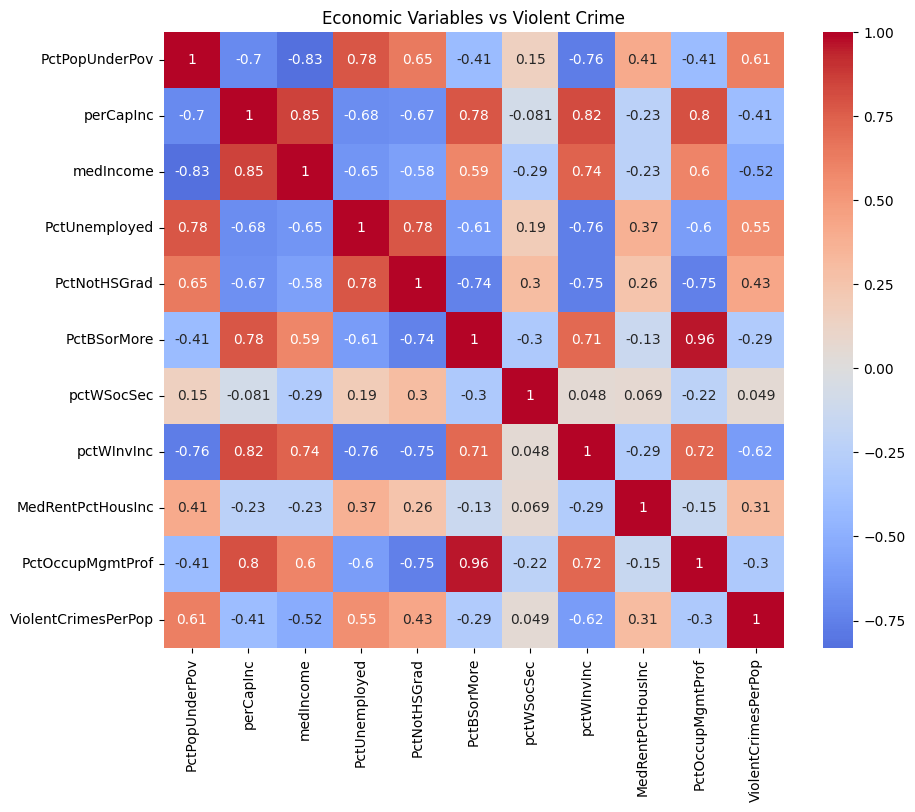

In [80]:
econ_corr = clean_df[economic_vars + target].corr()

plt.figure(figsize=(10,8))
sns.heatmap(
    econ_corr,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Economic Variables vs Violent Crime")
plt.show()

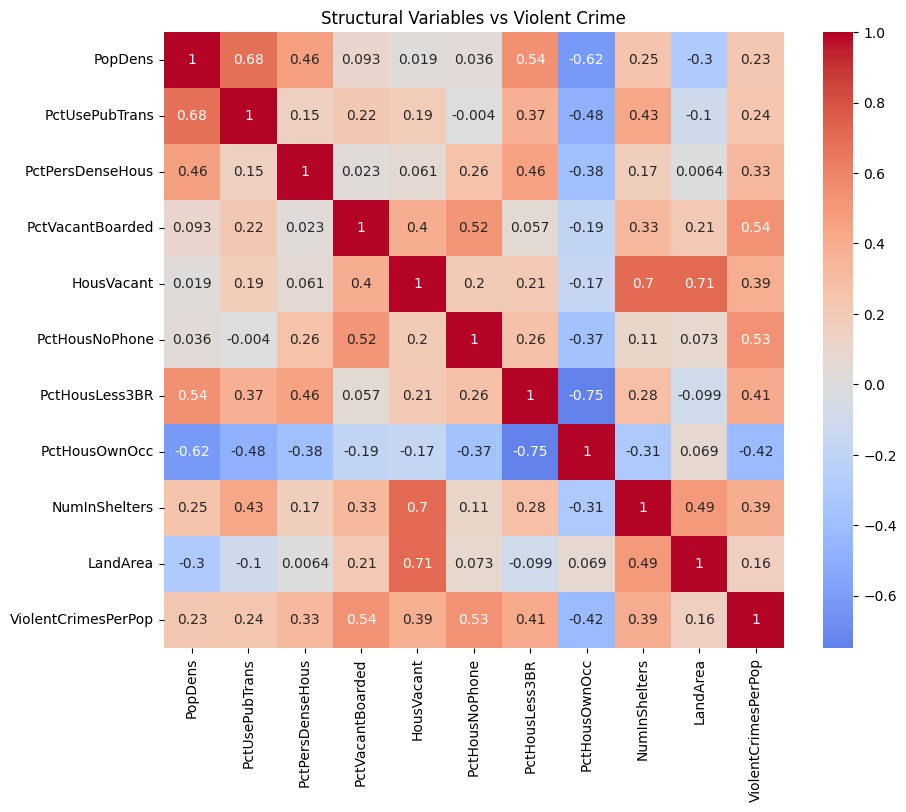

In [81]:
struct_corr = clean_df[structural_vars + target].corr()

plt.figure(figsize=(10,8))
sns.heatmap(
    struct_corr,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Structural Variables vs Violent Crime")
plt.show()

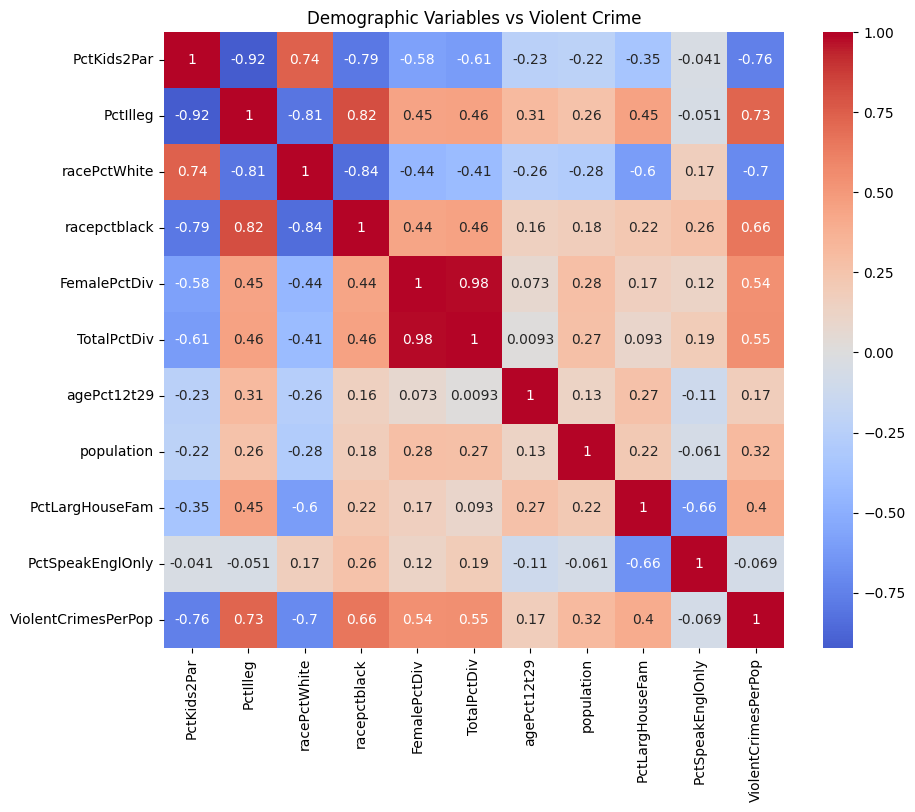

In [82]:
demo_corr = clean_df[demographic_vars + target].corr()

plt.figure(figsize=(10,8))
sns.heatmap(
    demo_corr,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Demographic Variables vs Violent Crime")
plt.show()

In [83]:
#Decision Tree classifyer with clean data:
# Create High Crime variable
threshold = 0.1

clean_df['HighCrime'] = (clean_df['ViolentCrimesPerPop'] > threshold).astype(int)


#Training:
X = clean_df[features]
y = clean_df['HighCrime']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

#DT model
dt_model = DecisionTreeClassifier(
    criterion='entropy',
    random_state=42
)

dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

print("Decision Tree Performance")
print("Accuracy:", accuracy_dt)
print("Precision:", precision_dt)
print("Recall:", recall_dt)
print("F1 Score:", f1_dt)

#10-fold cross validation
dt_cv_accuracy = cross_val_score(
    dt_model,
    X,
    y,
    cv=10,
    scoring='accuracy'
)

dt_importance = pd.Series(
    dt_model.feature_importances_,
    index=features
)
top5_dt = dt_importance.sort_values(ascending=False).head(5)

print("Decision Tree 10-Fold CV Accuracy:", dt_cv_accuracy.mean())
print("Top 5 Decision Tree Features:")
print(top5_dt)

Decision Tree Performance
Accuracy: 0.875
Precision: 0.9649122807017544
Recall: 0.9016393442622951
F1 Score: 0.9322033898305084
Decision Tree 10-Fold CV Accuracy: 0.9088709677419355
Top 5 Decision Tree Features:
pctWInvInc        0.349741
racePctWhite      0.149196
PctPopUnderPov    0.094875
HousVacant        0.084551
PctHousOwnOcc     0.082492
dtype: float64


Random Forest Performance
Accuracy: 0.96875
Precision: 0.9836065573770492
Recall: 0.9836065573770492
F1 Score: 0.9836065573770492
Random Forest 10-Fold CV Accuracy: 0.9213709677419356
PctPopUnderPov      0.135249
PctPersDenseHous    0.073070
pctWInvInc          0.069935
racePctWhite        0.059720
PctIlleg            0.052077
dtype: float64


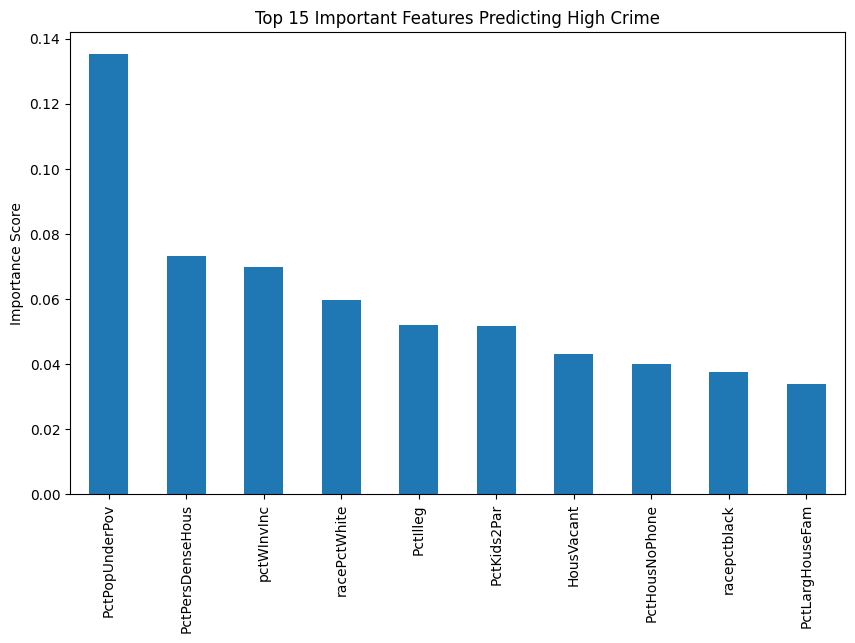

Top 5 Random Forest Features:
PctPopUnderPov      0.135249
PctPersDenseHous    0.073070
pctWInvInc          0.069935
racePctWhite        0.059720
PctIlleg            0.052077
dtype: float64


In [84]:
#Random Forest Classifies with clean data
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Random Forest Performance")
print("Accuracy:", accuracy_rf)
print("Precision:", precision_rf)
print("Recall:", recall_rf)
print("F1 Score:", f1_rf)

rf_cv_accuracy = cross_val_score(
    rf_model,
    X,
    y,
    cv=10,
    scoring='accuracy'
)

print("Random Forest 10-Fold CV Accuracy:", rf_cv_accuracy.mean())

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=features
).sort_values(ascending=False)

print(feature_importance.head(5))
plt.figure(figsize=(10,6))
feature_importance.head(10).plot(kind='bar')
plt.title("Top 15 Important Features Predicting High Crime")
plt.ylabel("Importance Score")

plt.show()

rf_importance = pd.Series(
    rf_model.feature_importances_,
    index=features
)

top5_rf = rf_importance.sort_values(ascending=False).head(5)
print("Top 5 Random Forest Features:")
print(top5_rf)

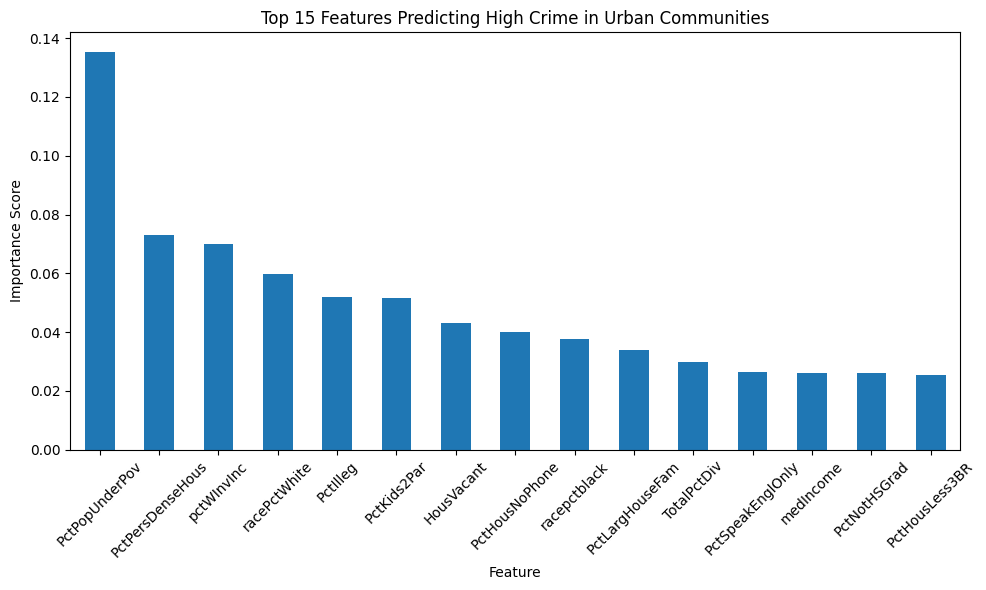

In [85]:
#Feature Importance Plot: shows which urban variables most influence crime prediction in Random forest
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=features
).sort_values(ascending=False)

plt.figure(figsize=(10,6))
feature_importance.head(15).plot(kind='bar')
plt.title("Top 15 Features Predicting High Crime in Urban Communities")
plt.ylabel("Importance Score")
plt.xlabel("Feature")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

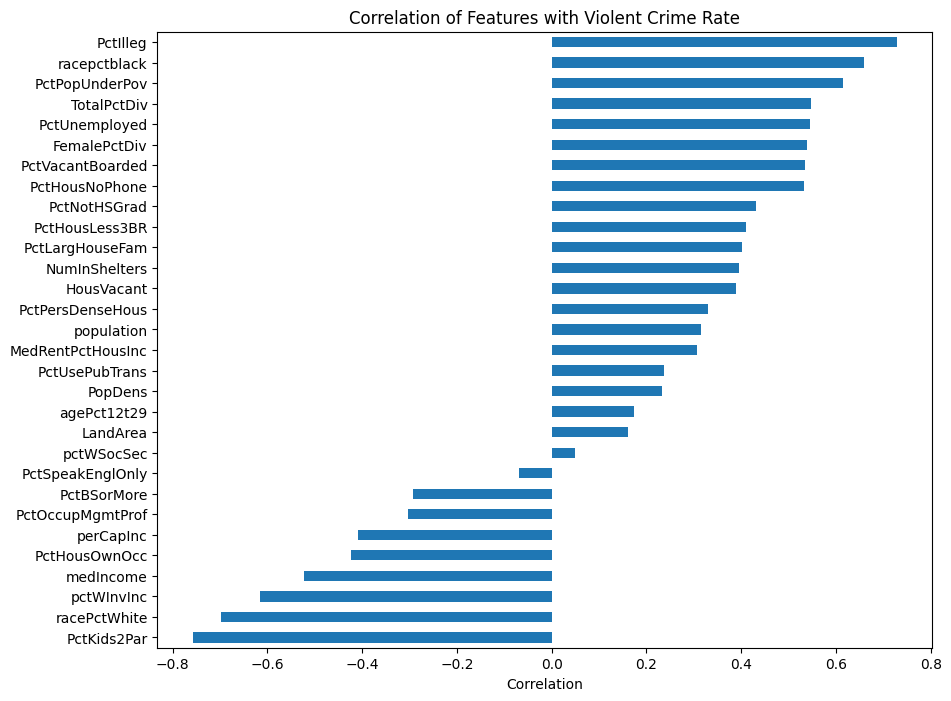

In [86]:
#Correlation Bar Chart with Crime (Not from a model)
crime_corr = clean_df[features + ['ViolentCrimesPerPop']].corr()['ViolentCrimesPerPop']
crime_corr = crime_corr.drop('ViolentCrimesPerPop').sort_values()
plt.figure(figsize=(10,8))
crime_corr.plot(kind='barh')
plt.title("Correlation of Features with Violent Crime Rate")
plt.xlabel("Correlation")
plt.show()

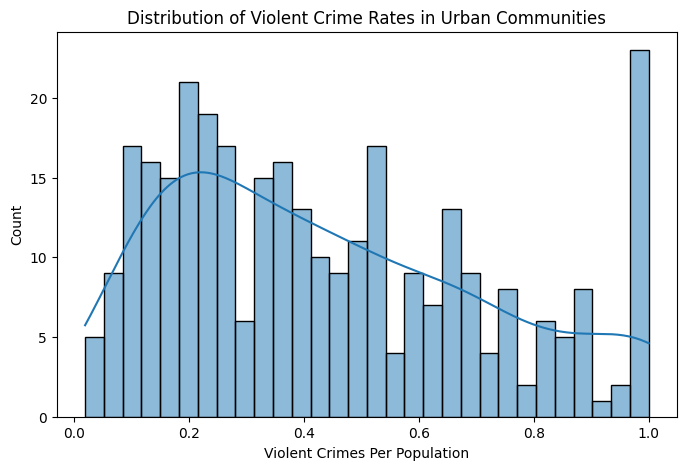

In [87]:
#Crime rate Dist. 
plt.figure(figsize=(8,5))

sns.histplot(
    clean_df['ViolentCrimesPerPop'],
    bins=30,
    kde=True
)

plt.title("Distribution of Violent Crime Rates in Urban Communities")
plt.xlabel("Violent Crimes Per Population")
plt.show()

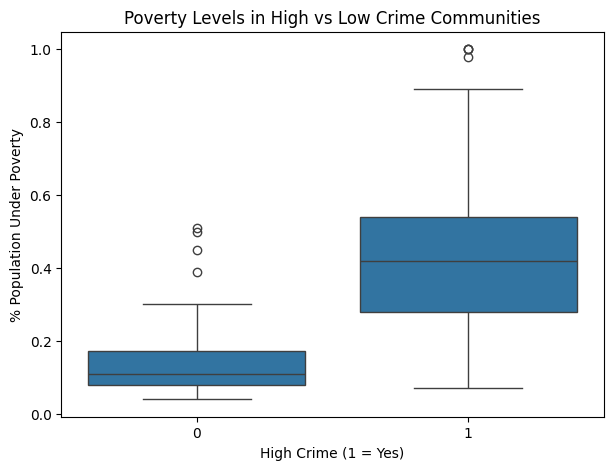

In [88]:
#Key Predictors vs Crime
plt.figure(figsize=(7,5))
sns.boxplot(
    x='HighCrime',
    y='PctPopUnderPov',
    data=clean_df
)

plt.title("Poverty Levels in High vs Low Crime Communities")
plt.xlabel("High Crime (1 = Yes)")
plt.ylabel("% Population Under Poverty")
plt.show()

In [89]:
#Lasso 
epsilon = 0.0001
clean_df['ViolentCrimesBeta'] = clean_df['ViolentCrimesPerPop'].clip(epsilon, 1-epsilon)
threshold = 0.1
clean_df['HighCrime'] = (clean_df['ViolentCrimesPerPop'] > threshold).astype(int)
X = clean_df[features]
y_reg = clean_df['ViolentCrimesPerPop']
y_beta = clean_df['ViolentCrimesBeta']
y_class = clean_df['HighCrime']

X_train, X_test, y_train_reg, y_test_reg = train_test_split(
    X, y_reg,
    test_size=0.2,
    random_state=42
)
_, _, y_train_class, y_test_class = train_test_split(
    X, y_class,
    test_size=0.2,
    random_state=42
)
lasso_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(alpha=0.01))
])

lasso_pipeline.fit(X_train, y_train_reg)
y_pred_lasso = lasso_pipeline.predict(X_test)
mse_lasso = mean_squared_error(y_test_reg, y_pred_lasso)
print("Lasso MSE:", mse_lasso)

y_pred_class = (y_pred_lasso > threshold).astype(int)
accuracy_lasso = accuracy_score(y_test_class, y_pred_class)
precision_lasso = precision_score(y_test_class, y_pred_class)
recall_lasso = recall_score(y_test_class, y_pred_class)
f1_lasso = f1_score(y_test_class, y_pred_class)
print("Accuracy:", accuracy_lasso)
print("Precision:", precision_lasso)
print("Recall:", recall_lasso)
print("F1 Score:", f1_lasso)

lasso_cv = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(alpha=0.01))
])

cv_scores = cross_val_score(
    lasso_cv,
    X,
    y_reg,
    cv=10,
    scoring='neg_mean_squared_error'
)
lasso_model = lasso_pipeline.named_steps['lasso']
print("10-Fold CV MSE:", -cv_scores.mean())
lasso_importance = pd.Series(
    lasso_model.coef_,
    index=features
)

top5_lasso = lasso_importance.abs().sort_values(ascending=False).head(5)
print("Top 5 Lasso Features:")
print(top5_lasso)



Lasso MSE: 0.025262597525979244
Accuracy: 0.96875
Precision: 0.9836065573770492
Recall: 0.9836065573770492
F1 Score: 0.9836065573770492
10-Fold CV MSE: 0.028350174166259234
Top 5 Lasso Features:
PctKids2Par     0.087683
racePctWhite    0.051899
HousVacant      0.025305
FemalePctDiv    0.021784
pctWInvInc      0.016763
dtype: float64


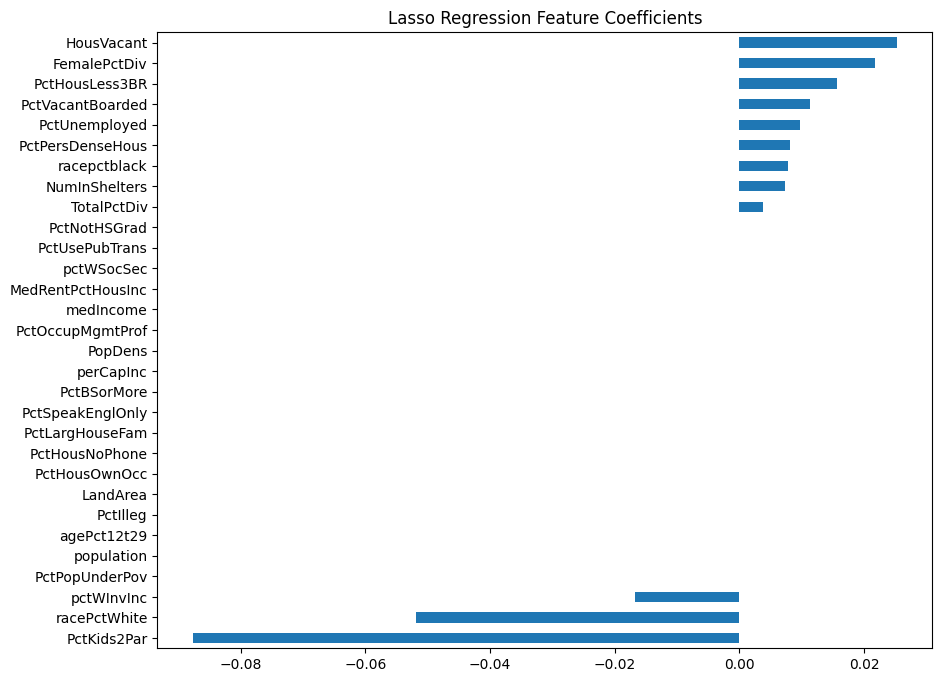

In [90]:
lasso_model = lasso_pipeline.named_steps['lasso']

coefficients = pd.Series(
    lasso_model.coef_,
    index=features
)

coefficients = coefficients.sort_values()
plt.figure(figsize=(10,8))
coefficients.plot(kind='barh')
plt.title("Lasso Regression Feature Coefficients")
plt.show()

In [91]:
#Beta Regression
X_beta = sm.add_constant(X)
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_beta,
    y_beta,
    test_size=0.2,
    random_state=42
    
)

beta_model = BetaModel(y_train_b, X_train_b)
beta_results = beta_model.fit()

#print(beta_results.summary())
y_pred_beta = beta_results.predict(X_test_b)
mse_beta = mean_squared_error(y_test_b, y_pred_beta)
print("Beta Regression MSE:", mse_beta)

y_pred_class_beta = (y_pred_beta > threshold).astype(int)
accuracy_beta = accuracy_score(y_test_class, y_pred_class_beta)
precision_beta = precision_score(y_test_class, y_pred_class_beta)
recall_beta = recall_score(y_test_class, y_pred_class_beta)
f1_beta = f1_score(y_test_class, y_pred_class_beta)

print("Accuracy:", accuracy_beta)
print("Precision:", precision_beta)
print("Recall:", recall_beta)
print("F1 Score:", f1_beta)

beta_importance = pd.Series(
    beta_results.params[1:], 
    index=features
)

top5_beta = beta_importance.abs().sort_values(ascending=False).head(5)
print("Top 5 Beta Regression Features:")
print(top5_beta)

Beta Regression MSE: 0.03459197090505573
Accuracy: 0.9375
Precision: 0.9523809523809523
Recall: 0.9836065573770492
F1 Score: 0.967741935483871
Top 5 Beta Regression Features:
pctWInvInc      4.804100
PctBSorMore     4.386860
PctKids2Par     2.906298
PctNotHSGrad    2.872266
population      2.601251
dtype: float64


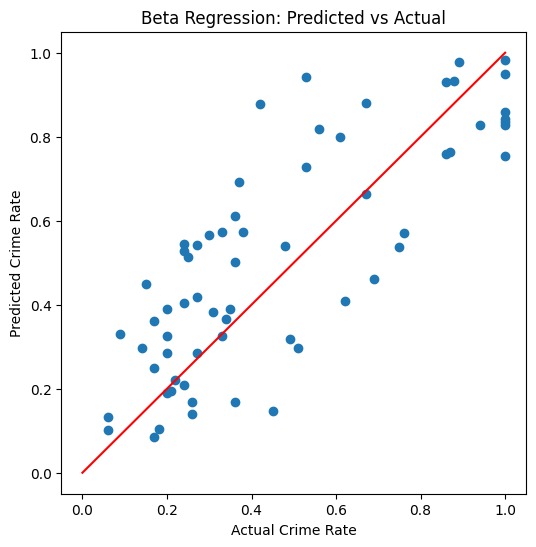

In [92]:
plt.figure(figsize=(6,6))
plt.scatter(y_test_b, y_pred_beta)
plt.xlabel("Actual Crime Rate")
plt.ylabel("Predicted Crime Rate")
plt.title("Beta Regression: Predicted vs Actual")
plt.plot([0,1], [0,1], color='red')
plt.show()

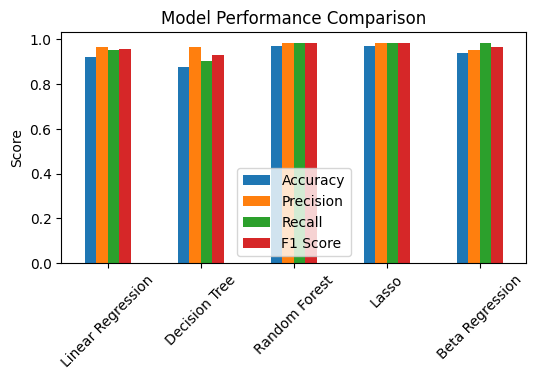

In [93]:
results = pd.DataFrame({
    'Accuracy': [accuracy, accuracy_dt, accuracy_rf, accuracy_lasso, accuracy_beta],
    'Precision': [precision, precision_dt, precision_rf, precision_lasso, precision_beta],
    'Recall': [recall, recall_dt, recall_rf, recall_lasso, recall_beta],
    'F1 Score': [f1, f1_dt, f1_rf, f1_lasso, f1_beta]
},
index=[
    'Linear Regression',
    'Decision Tree',
    'Random Forest',
    'Lasso',
    'Beta Regression'
])

results.plot(kind='bar', figsize=(6,3))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()

In [94]:
top_features = pd.DataFrame({
    "Linear": top5_linear.index,
    "DecisionTree": top5_dt.index,
    "RandomForest": top5_rf.index,
    "Lasso": top5_lasso.index,
    "Beta": top5_beta.index
})

print(top_features)

          Linear    DecisionTree      RandomForest         Lasso          Beta
0     pctWInvInc      pctWInvInc    PctPopUnderPov   PctKids2Par    pctWInvInc
1   PctNotHSGrad    racePctWhite  PctPersDenseHous  racePctWhite   PctBSorMore
2    PctBSorMore  PctPopUnderPov        pctWInvInc    HousVacant   PctKids2Par
3    PctKids2Par      HousVacant      racePctWhite  FemalePctDiv  PctNotHSGrad
4  PctHousOwnOcc   PctHousOwnOcc          PctIlleg    pctWInvInc    population


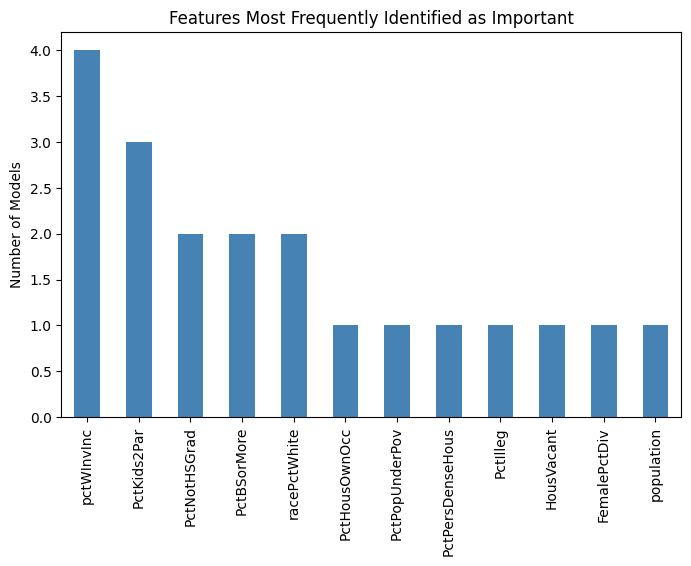

In [95]:
feature_counts = pd.Series(
    list(top5_linear.index) +
    list(top5_rf.index) +
    list(top5_lasso.index) +
    list(top5_beta.index)
).value_counts()

plt.figure(figsize=(8,5))
feature_counts.plot(kind='bar', color='steelblue')
plt.title("Features Most Frequently Identified as Important")
plt.ylabel("Number of Models")
plt.show()

pctWInvInc          19
PctKids2Par         10
racePctWhite        10
PctPopUnderPov       8
PctBSorMore          7
PctNotHSGrad         6
HousVacant           5
PctPersDenseHous     4
PctHousOwnOcc        2
FemalePctDiv         2
PctIlleg             1
population           1
dtype: int64


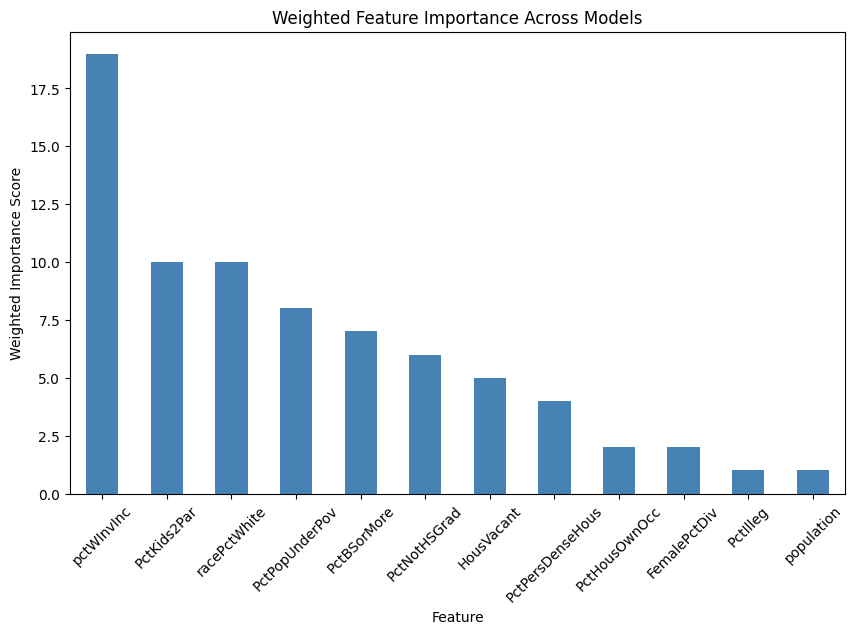

In [96]:
weights = [5,4,3,2,1]
feature_scores = {}

def add_scores(top_features):
    for i, feature in enumerate(top_features.index):
        score = weights[i]
        feature_scores[feature] = feature_scores.get(feature,0) + score

add_scores(top5_linear)
add_scores(top5_dt)
add_scores(top5_rf)
add_scores(top5_lasso)
add_scores(top5_beta)

feature_scores = pd.Series(feature_scores).sort_values(ascending=False)
print(feature_scores)
plt.figure(figsize=(10,6))

feature_scores.plot(
    kind="bar",
    color="steelblue"
)

plt.title("Weighted Feature Importance Across Models")
plt.xlabel("Feature")
plt.ylabel("Weighted Importance Score")
plt.xticks(rotation=45)
plt.show()